# Customer Retention EDA

This notebook explores the customer churn dataset used by the **Customer Churn Risk Intelligence** project.

The analysis focuses on customer composition, churn distribution, tenure, billing, contracts, services, and other observable characteristics associated with churn.

The raw dataset is loaded through the project's reusable validation utilities rather than duplicating data-cleaning logic inside the notebook.

## 1. Project Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DATA_PATH
from src.features import add_features
from src.validate_data import load_prepared_data

pd.set_option("display.max_columns", None)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {RAW_DATA_PATH}")

Project root: D:\00-quality-projects\customer-churn-risk-intelligence
Dataset path: D:\00-quality-projects\customer-churn-risk-intelligence\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


## 2. Load the Raw Dataset

The project uses a single source CSV. Data validation and basic preparation are handled by `src.validate_data`.

In [2]:
df = load_prepared_data(RAW_DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Dataset Structure

In [3]:
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDuplicate customer IDs:", df["customerID"].duplicated().sum())
print("Missing values:", df.isna().sum().sum())

Dataset shape: (7043, 21)

Data types:


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str



Duplicate customer IDs: 0
Missing values: 0


## 4. Numerical Summary

In [4]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.798992,2266.730170,18.80,398.55,1394.55,3786.60,8684.80


## 5. Churn Distribution

The target variable is converted to binary form by the shared data-preparation function: `0` represents no churn and `1` represents churn.

In [5]:
churn_counts = df["Churn"].value_counts().sort_index()
churn_rates = df["Churn"].value_counts(normalize=True).sort_index()

churn_summary = pd.DataFrame(
    {
        "Count": churn_counts,
        "Share": churn_rates,
    }
)

display(churn_summary.style.format({"Share": "{:.2%}"}))

,Count,Share
Churn,,
0,5174,73.46%
1,1869,26.54%


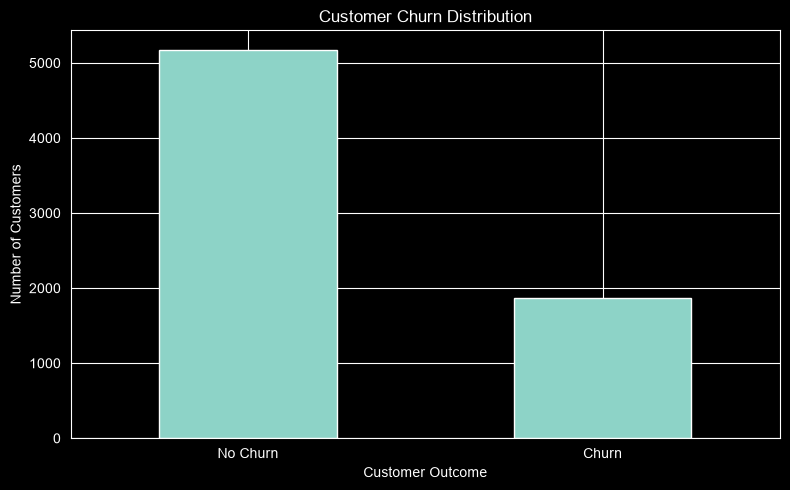

In [6]:
ax = churn_counts.rename({0: "No Churn", 1: "Churn"}).plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Customer Outcome")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Contract and Churn

Contract type is examined as a customer-segmentation variable. The analysis is descriptive and does not imply that contract type itself causes churn.

In [7]:
def churn_summary(data, column):
    result = (
        data.groupby(column)["Churn"]
        .agg(["count", "mean"])
        .rename(
            columns={
                "count": "Customers",
                "mean": "ChurnRate",
            }
        )
        .sort_values("ChurnRate", ascending=False)
    )
    return result

contract_summary = churn_summary(df, "Contract")
display(contract_summary.style.format({"ChurnRate": "{:.2%}"}))

,Customers,ChurnRate
Contract,,
Month-to-month,3875,42.71%
One year,1473,11.27%
Two year,1695,2.83%


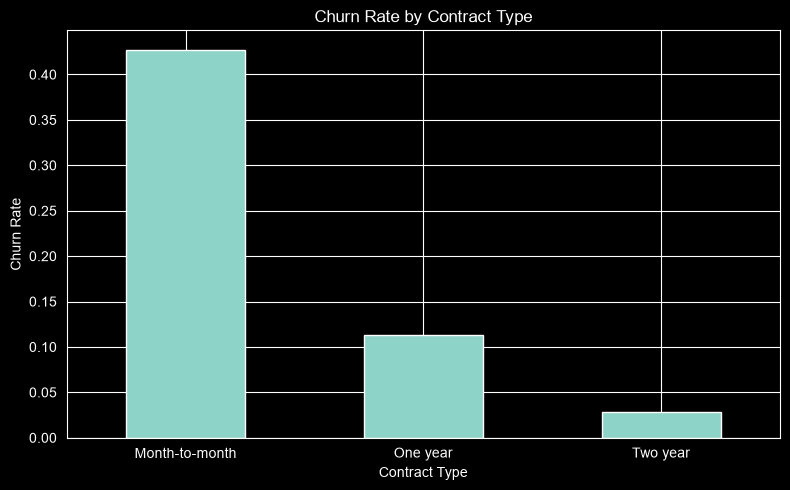

In [8]:
ax = (
    contract_summary["ChurnRate"]
    .plot(kind="bar", figsize=(8, 5))
)

ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Payment Method and Churn

In [9]:
payment_summary = churn_summary(df, "PaymentMethod")
display(payment_summary.style.format({"ChurnRate": "{:.2%}"}))

,Customers,ChurnRate
PaymentMethod,,
Electronic check,2365,45.29%
Mailed check,1612,19.11%
Bank transfer (automatic),1544,16.71%
Credit card (automatic),1522,15.24%


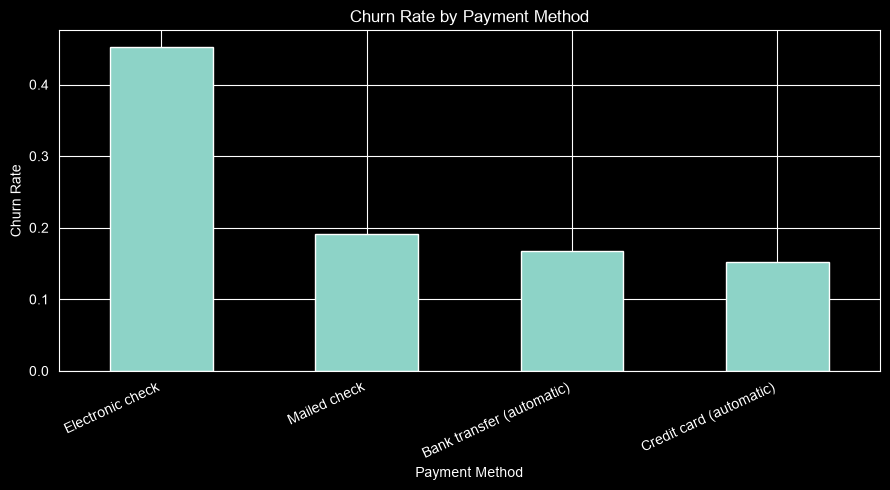

In [10]:
ax = (
    payment_summary["ChurnRate"]
    .plot(kind="bar", figsize=(9, 5))
)

ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Payment Method")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 8. Internet Service and Churn

In [11]:
internet_summary = churn_summary(df, "InternetService")
display(internet_summary.style.format({"ChurnRate": "{:.2%}"}))

,Customers,ChurnRate
InternetService,,
Fiber optic,3096,41.89%
DSL,2421,18.96%
No,1526,7.40%


## 9. Customer Tenure

Tenure is grouped into practical lifecycle bands to examine whether churn concentration differs across customer age.

In [12]:
tenure_bins = [-1, 6, 12, 24, 48, 72]
tenure_labels = [
    "0-6 months",
    "7-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months",
]

df["TenureBand"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
)

tenure_summary = (
    df.groupby("TenureBand", observed=False)["Churn"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "Customers",
            "mean": "ChurnRate",
        }
    )
)

display(tenure_summary.style.format({"ChurnRate": "{:.2%}"}))

,Customers,ChurnRate
TenureBand,,
0-6 months,1481,52.94%
7-12 months,705,35.89%
13-24 months,1024,28.71%
25-48 months,1594,20.39%
49-72 months,2239,9.51%


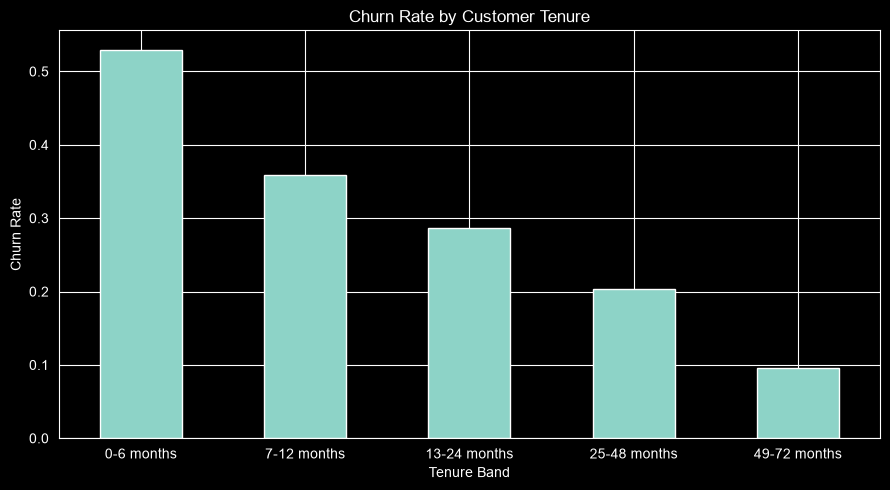

In [13]:
ax = tenure_summary["ChurnRate"].plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Churn Rate by Customer Tenure")
ax.set_xlabel("Tenure Band")
ax.set_ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Monthly Charges and Churn

In [14]:
charge_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .rename(index={0: "No Churn", 1: "Churn"})
)

display(charge_summary)

,count,mean,median
Churn,,,
No Churn,5174,61.265124,64.425
Churn,1869,74.441332,79.650


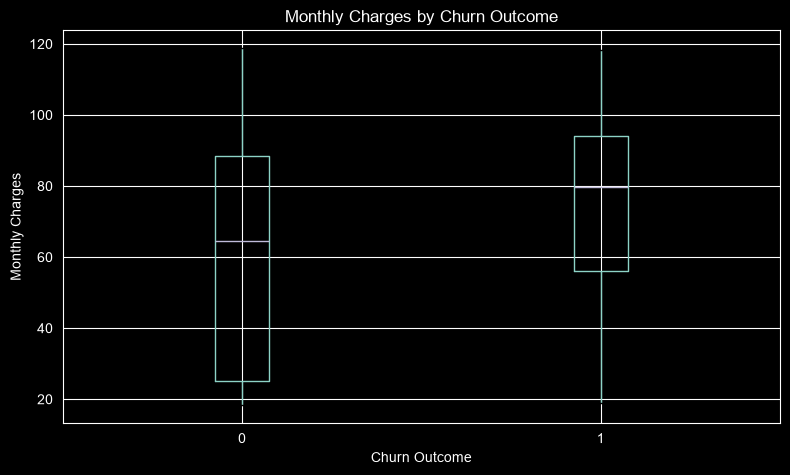

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    ax=ax,
)

ax.set_title("Monthly Charges by Churn Outcome")
ax.set_xlabel("Churn Outcome")
ax.set_ylabel("Monthly Charges")
plt.suptitle("")
plt.tight_layout()
plt.show()

## 11. Service Adoption

The project creates a simple service-adoption measure based on optional services.

In [16]:
df_features = add_features(df)

service_features = [
    "ServiceAdoptionCount",
    "ServiceAdoptionRate",
]

display(df_features[service_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
ServiceAdoptionCount,7043.0,2.037910,1.847682,0.0,0.0,2.000000,3.0,6.0
ServiceAdoptionRate,7043.0,0.339652,0.307947,0.0,0.0,0.333333,0.5,1.0


In [17]:
service_churn = (
    df_features.groupby("ServiceAdoptionCount")["Churn"]
    .agg(["count", "mean"])
    .rename(
        columns={
            "count": "Customers",
            "mean": "ChurnRate",
        }
    )
)

display(service_churn.style.format({"ChurnRate": "{:.2%}"}))

,Customers,ChurnRate
ServiceAdoptionCount,,
0,2219,21.41%
1,966,45.76%
2,1033,35.82%
3,1118,27.37%
4,852,22.30%
5,571,12.43%
6,284,5.28%


## 12. Engineered Features

The modeling pipeline uses several derived features intended to capture customer lifecycle, financial exposure, service adoption, contract structure, and payment behavior.

In [18]:
engineered_features = [
    "LifetimeSpendPerTenure",
    "MonthlyCostExposure",
    "ServiceAdoptionCount",
    "ServiceAdoptionRate",
    "IsRollingContract",
    "IsLongContract",
    "EarlyLifecycleRolling",
    "AccumulatedValueRatio",
    "UsesElectronicPayment",
]

display(df_features[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
LifetimeSpendPerTenure,7043.0,64.762906,30.189796,13.775000,35.935156,70.337500,90.174158,121.400000
MonthlyCostExposure,7043.0,0.158908,0.283248,0.012604,0.018101,0.034876,0.114716,1.000000
ServiceAdoptionCount,7043.0,2.037910,1.847682,0.000000,0.000000,2.000000,3.000000,6.000000
ServiceAdoptionRate,7043.0,0.339652,0.307947,0.000000,0.000000,0.333333,0.500000,1.000000
IsRollingContract,7043.0,0.550192,0.497510,0.000000,0.000000,1.000000,1.000000,1.000000
IsLongContract,7043.0,0.240664,0.427517,0.000000,0.000000,0.000000,0.000000,1.000000
EarlyLifecycleRolling,7043.0,0.283118,0.450545,0.000000,0.000000,0.000000,1.000000,1.000000
AccumulatedValueRatio,7043.0,1.000274,0.051119,0.689356,0.979623,1.000000,1.019491,1.573454
UsesElectronicPayment,7043.0,0.335794,0.472301,0.000000,0.000000,0.000000,1.000000,1.000000


## 13. Key Observations

The following cells summarize the strongest descriptive differences found in the dataset. These findings should be treated as associations rather than causal conclusions.

In [19]:
highest_contract_churn = (
    df.groupby("Contract")["Churn"]
    .mean()
    .idxmax()
)

highest_payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .mean()
    .idxmax()
)

highest_internet_churn = (
    df.groupby("InternetService")["Churn"]
    .mean()
    .idxmax()
)

highest_tenure_band = tenure_summary["ChurnRate"].idxmax()

print("Key EDA observations")
print("=" * 40)
print(f"Highest churn contract group: {highest_contract_churn}")
print(f"Highest churn payment-method group: {highest_payment_churn}")
print(f"Highest churn internet-service group: {highest_internet_churn}")
print(f"Highest churn tenure band: {highest_tenure_band}")

Key EDA observations
Highest churn contract group: Month-to-month
Highest churn payment-method group: Electronic check
Highest churn internet-service group: Fiber optic
Highest churn tenure band: 0-6 months


## 14. Conclusion

The EDA identifies customer segments and observable characteristics that can be useful for churn-risk modeling. The modeling notebook uses these variables together with engineered features to compare several classification approaches.

EDA findings are descriptive. They should not be interpreted as evidence that a particular customer characteristic directly causes churn.